In [1]:
%cd ..

/Users/rubenmarcus/Desktop/Code/Personal Projects/Deep Hedging/deep_hedging


In [2]:
import numpy as np
import math

from src.models.gbm import simulate_gbm
from src.derivatives.european_call import (
    black_scholes_call,
    black_scholes_delta
)
from src.strategies.delta_hedge import delta_hedge_path

In [3]:
stock_path = [100, 95, 90, 100, 105]
K = 100
sigma = 0.20
T = 1.0

result = delta_hedge_path(
    stock_path=stock_path,
    K=K,
    sigma=sigma,
    T=T
)

initial_portfolio = result["deltas"][0] * stock_path[0] + result["cash_balances"][0]

print(initial_portfolio)
print(result["option_premium"])

7.965567455405804
7.965567455405804


In [4]:
K = 100
sigma = 0.20
T = 30 / 252
n_steps = 30
r = 0.0

paths = simulate_gbm(
    S0=100,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=1,
    seed=123
)

stock_path = paths[0]

result = delta_hedge_path(
    stock_path=stock_path,
    K=K,
    sigma=sigma,
    T=T,
    r=r 
)

print('stock path:')
print(result["stock_path"])

print("\ndeltas:")
print(result["deltas"])

print("\ntrades:")
print(result["trades"])

print("\ncash:")
print(result["cash_balances"])

print("\nterminal option payoff:")
print(result["payoff"])

print("\nterminal hedge portfolio:")
print(result["terminal_portfolio"])

stock path:
[100.          98.75371894  98.28938366  99.88934166 100.12580775
 101.28536483 102.01637979 101.19358174 101.87880539 101.46519482
 101.0458875  101.16163391  99.22750979 100.72115008  99.86522311
 101.12368313 101.28947158 103.25533593 102.39221784 101.98269082
 102.40947391  99.59264736 100.6289314  102.59438017 104.05298319
 105.0388269  104.83750166 106.53596557 107.978786   108.50562061
 108.50400055]

deltas:
[0.51376209 0.44001876 0.41080328 0.506311   0.52061295 0.5926015
 0.63844352 0.58962594 0.63477755 0.6105702  0.58427194 0.59396826
 0.45289333 0.56525296 0.49937591 0.60002035 0.61614051 0.76667015
 0.71345083 0.68819561 0.73155498 0.46450231 0.57681737 0.78378957
 0.90368371 0.96071875 0.97044889 0.99820583 0.9999921  1.        ]

trades:
[ 5.13762086e-01 -7.37433227e-02 -2.92154826e-02  9.55077169e-02
  1.43019574e-02  7.19885472e-02  4.58420210e-02 -4.88175814e-02
  4.51516089e-02 -2.42073489e-02 -2.62982599e-02  9.69631748e-03
 -1.41074932e-01  1.12359637e

In [5]:
import matplotlib.pyplot as plt

def despine(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    return ax

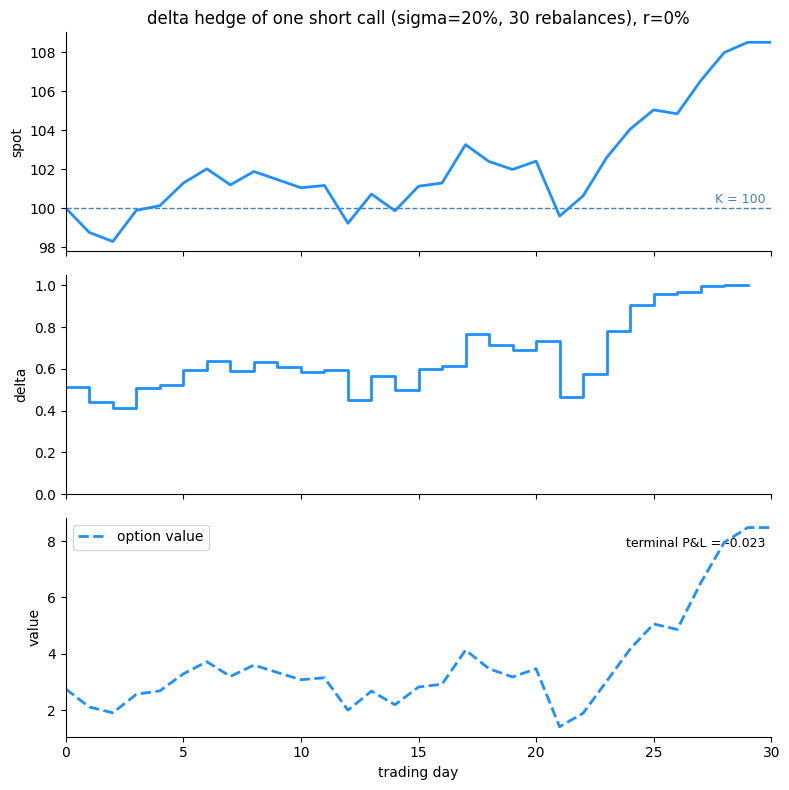

In [9]:
times = result["times"]
days = times * 252
S = result["stock_path"]
deltas = result["deltas"]
cash = result["cash_balances"]

portfolio = np.empty(n_steps + 1)
portfolio[:n_steps] = deltas * S[:n_steps] + cash
portfolio[-1] = result["terminal_portfolio"]

option_values = np.array([
    black_scholes_call(S=S[i], K=K, sigma=sigma, T=T, t=times[i], r=r)
    for i in range(n_steps + 1)
])

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

ax = axes[0]
ax.plot(days, S, color="dodgerblue", linewidth=2)
ax.axhline(K, color="steelblue", linewidth=1, linestyle="--", zorder=0)
ax.annotate(f"K = {K}", xy=(days[-1], K), xytext=(-4, 4),
            textcoords="offset points", ha="right", color="steelblue", fontsize=9)
ax.set_ylabel("spot")
ax.set_title(f"delta hedge of one short call (sigma={sigma:.0%}, {n_steps} rebalances), r={r:.0%}")

ax = axes[1]
ax.step(days[:-1], deltas, where="post", color="dodgerblue", linewidth=2)
ax.set_ylabel("delta")
ax.set_ylim(0, 1.05)

ax = axes[2]
ax.plot(days, portfolio, color="dodgerblue", linewidth=2, linestyle="--", label="option value")
ax.set_ylabel("value")
ax.set_xlabel("trading day")
ax.legend(loc="upper left")
ax.annotate(f"terminal P&L = {result["hedging_pnl"]:+.3f}",
            xy=(days[-1], portfolio[-1]), xytext=(-4, -14),
                textcoords="offset points", ha="right", fontsize=9)

for a in axes:
    despine(a)
    a.set_xlim(0, days[-1])

fig.tight_layout()
plt.show()


In [17]:
n_paths = 2000

mc_paths = simulate_gbm(
    S0=100,
    sigma=sigma,
    T=T,
    n_steps=n_steps,
    n_paths=n_paths,
    r=r,
    seed=123)

pnls = np.array([
    delta_hedge_path(p, K=K, sigma=sigma, T=T, r=r)["hedging_pnl"]
    for p in mc_paths
])

premium = black_scholes_call(S=100, K=K, sigma=sigma, T=T, r=r)

print("premium: ", premium)
print("mean P&L:", pnls.mean())
print("std P&L: ", pnls.std(), f"({pnls.std() / premium:.1%} of premium)")

premium:  2.7524171533585005
mean P&L: -0.002105601984779658
std P&L:  0.4322451508410737 (15.7% of premium)


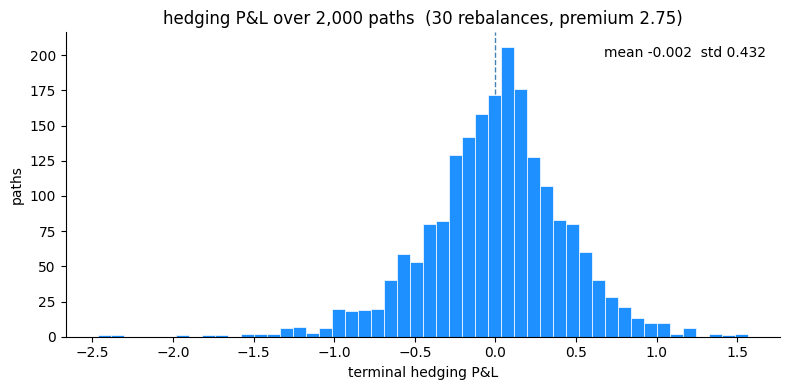

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(pnls, bins=50, color='dodgerblue', edgecolor="white", linewidth=0.5)
ax.axvline(0, color="steelblue", linewidth=1, linestyle="--", zorder=0)
ax.annotate(f"mean {pnls.mean():+.3f}  std {pnls.std():.3f}",
            xy=(0.98, 0.92), xycoords="axes fraction", ha="right")

ax.set_title(f"hedging P&L over {n_paths:,} paths  ({n_steps} rebalances, premium {premium:.2f})")
ax.set_xlabel("terminal hedging P&L")
ax.set_ylabel("paths")
despine(ax)
fig.tight_layout()
plt.show()

In [ ]:
step_grid = [5, 10, 15, 30, 60, 120, 240]

n_paths_conv = 2000

pnl_std = []
for n in step_grid:
    p = simulate_gbm(
        S0=100,
        sigma=sigma,
        T=T,
        n_steps=n,
        n_paths=n_paths_conv,
        r=r,
        seed=123)

    s = np.array([
        delta_hedge_path(row, K=K, sigma=sigma, T=T, r=r)["hedging_pnl"]
        for row in p
    ])
    pnl_std.append(s.std())
    print(f"n_steps={n:4d}  std={s.std():.4f}")

pnl_std = np.array(pnl_std)

n_steps=   5  std=1.0061


AttributeError: 'numpy.ndarray' object has no attribute 'append'